In [3]:
import gymnasium as gym 
from collections import defaultdict
import numpy as np 

Q-table entry looks like
> (18,10,False) → [Q_stand, Q_hit]

Example:
> (18,10,False) → [0.3, -0.2]


In [ ]:
class BlackjackAgent :
    def __init__(
            self,
            env : gym.Env,
            learning_rate  : float,
            initial_epsilon: float,    # control exploration
            epsilon_decay: float,
            final_epsilon : float,
            discount_factor : float = 0.95):
        
        self.env = env

        #Q table 

        self.q_values = defaultdict(lambda : np.zeros(env.action_space.n))
        self.lr = learning_rate
        self.dis_f = discount_factor  #how much care about future rewards

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []

    def get_action (self, obs:tuple[int,int,bool]) -> int:

        if np.random.random() < self.epsilon :
            return self.env.action_space.sample()      #return random action
            
        else:
            return int (np.argmax(self.q_values[obs]))      # return action index of highest reward
        
    def update(
        self,
        obs:tuple[int,int,bool],
        action : int,
        reward : float,
        terminated : bool,
        next_obs : tuple[int,int,bool] ,
    ):
        future_q_values = (not terminated) * np.max(self.q_values[next_obs])  # if game ended  0  else max Q(next_state

        target = reward + self.dis_f*future_q_values       # What we actually experienced: reward + discounted future value 

        temporal_difference  = target - self.q_values[obs][action]   # how wrong estimation was

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr*temporal_difference
        )

        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon , self.epsilon - self.epsilon_decay)
        

        

### Training the agent

In [26]:
learning_rate = 0.001
n_episodes = 100000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes/2)
final_epsilon = 0.01

env = gym.make("Blackjack-v1",sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env , buffer_length=n_episodes)  #automatically tracks how well your agent is performing (progress)

agent = BlackjackAgent(
    env = env,
    learning_rate=learning_rate,
    initial_epsilon = start_epsilon,
    epsilon_decay = epsilon_decay,
    final_epsilon  = final_epsilon,
)

Training Loop

In [27]:
from tqdm import tqdm   #progress bar to loops

for episode in tqdm(range(n_episodes)):
    obs , info = env.reset()
    done = False

    while not done:
        #choose action
        action = agent.get_action(obs)

        #take action
        next_obs , reward , terminated , truncated,info = env.step(action)

        #learn from experience
        agent.update(obs , action,reward , terminated,next_obs)

        #move to  next state
        obs = next_obs
        done = terminated or truncated
    agent.decay_epsilon()



100%|██████████| 100000/100000 [00:17<00:00, 5603.84it/s]


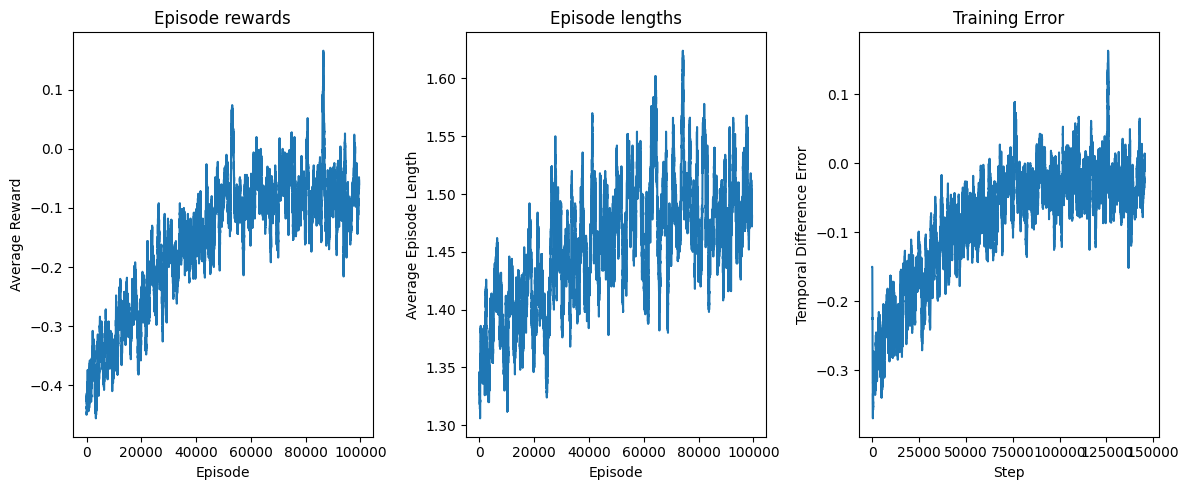

In [28]:
import matplotlib.pyplot as plt 

def get_moving_avgs(arr,window, convolution_mode):

    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    )/window

rolling_length = 500
fig,axs = plt.subplots(ncols=3, figsize = (12,5))


axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)

axs[0].plot(range(len(reward_moving_average)),reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show() 

In [32]:
def test_agent(agent,env,num_episodes=1000):

    total_rewards = []

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    for i in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0
        done = False

        while not done :
            action = agent.get_action(obs)
            obs,reward , terminated , truncated,info = env.step(action)
            episode_reward += reward
            done = terminated or truncated
        total_rewards.append(episode_reward)
    agent.epsilon = old_epsilon
    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)

    print(f"Test results over {num_episodes} episodes : " )
    print(f"win rate : {win_rate :.1%}")
    print(f"average reward : {average_reward:.3f}")
    print(f"standard deviation : {np.std(total_rewards):.3f}")


test_agent(agent,env)

Test results over 1000 episodes : 
win rate : 37.8%
average reward : -0.158
standard deviation : 0.943
